# Machine Learning Part 2: Data Preparation & Model Selection

## Making Your Models Better!

### What We'll Learn Today 

1. **Data Cleaning & Preparation** 
2. **Feature Engineering - Getting Creative!** 
3. **Understanding More Metrics** 
4. **Overfitting vs Underfitting** 
5. **Cross-Validation** 
6. **Comparing Different Algorithms** 
7. **Feature Importance** 
8. **Hyperparameter Tuning** 
9. **Choosing the Best Model** 

---

### Prerequisites
- Completed Part 1 (Linear Regression & Logistic Regression)
- Understanding of basic metrics (MAE, Accuracy)

### Our Goal Today
**Build BETTER models by:**
- Creating smart features
- Trying different algorithms
- Choosing the best one scientifically!

## Setup

In [1]:
# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# For data preparation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Algorithms - keeping it simple!
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load our car data
df = pd.read_csv('CarPrice_Assignment.csv')
print(f"Dataset loaded: {df.shape[0]} cars, {df.shape[1]} features")
df.head(3)

Dataset loaded: 205 cars, 26 features


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0


## Part 1: Data Cleaning & Preparation

### Real data is messy! Let's clean it up.

In [3]:
# Check for missing values
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [4]:
# Let's create some missing values to learn how to handle them
# (In real life, data often has missing values!)

# Make a copy to practice
df_practice = df.copy()

# Randomly remove 10 horsepower values
import random
random.seed(42)
missing_indices = random.sample(range(len(df_practice)), 10)
df_practice.loc[missing_indices, 'horsepower'] = np.nan

In [5]:
df_practice.isnull().sum()

car_ID               0
symboling            0
CarName              0
fueltype             0
aspiration           0
doornumber           0
carbody              0
drivewheel           0
enginelocation       0
wheelbase            0
carlength            0
carwidth             0
carheight            0
curbweight           0
enginetype           0
cylindernumber       0
enginesize           0
fuelsystem           0
boreratio            0
stroke               0
compressionratio     0
horsepower          10
peakrpm              0
citympg              0
highwaympg           0
price                0
dtype: int64

In [6]:
# Simple ways to handle missing values
print("THREE SIMPLE WAYS TO HANDLE MISSING VALUES:\n")

# Method 1: Remove rows with missing values
method1 = df_practice.dropna()
print(f"1. Remove rows: {len(df_practice)} → {len(method1)} cars (lost {len(df_practice)-len(method1)} cars)")

# Method 2: Fill with average
method2 = df_practice.copy()
avg_hp = method2['horsepower'].mean()
method2['horsepower'].fillna(avg_hp, inplace=True)
print(f"2. Fill with average: Used {avg_hp:.0f} HP for missing values")

# Method 3: Fill with median (better if there are outliers)
method3 = df_practice.copy()
median_hp = method3['horsepower'].median()
method3['horsepower'].fillna(median_hp, inplace=True)
print(f"3. Fill with median: Used {median_hp:.0f} HP for missing values")

# For this tutorial, we'll use the original complete data

THREE SIMPLE WAYS TO HANDLE MISSING VALUES:

1. Remove rows: 205 → 195 cars (lost 10 cars)
2. Fill with average: Used 105 HP for missing values
3. Fill with median: Used 95 HP for missing values


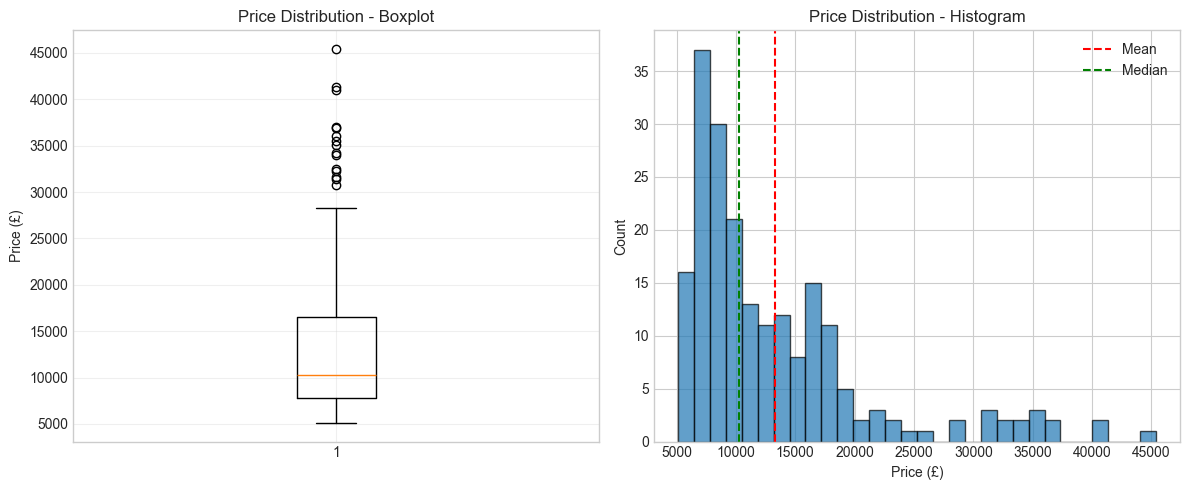

In [7]:
# Finding and handling outliers
# Simple outlier detection using boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
axes[0].boxplot(df['price'])
axes[0].set_ylabel('Price (£)')
axes[0].set_title('Price Distribution - Boxplot')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(df['price'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df['price'].mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(df['price'].median(), color='green', linestyle='--', label='Median')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution - Histogram')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Find outliers using IQR method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)]

In [9]:
outliers

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
15,16,0,bmw x4,gas,std,four,sedan,rwd,front,103.5,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,30760.0
16,17,0,bmw x5,gas,std,two,sedan,rwd,front,103.5,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,41315.0
17,18,0,bmw x3,gas,std,four,sedan,rwd,front,110.0,...,209,mpfi,3.62,3.39,8.0,182,5400,15,20,36880.0
47,48,0,jaguar xj,gas,std,four,sedan,rwd,front,113.0,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,32250.0
48,49,0,jaguar xf,gas,std,four,sedan,rwd,front,113.0,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,35550.0
49,50,0,jaguar xk,gas,std,two,sedan,rwd,front,102.0,...,326,mpfi,3.54,2.76,11.5,262,5000,13,17,36000.0
70,71,-1,buick skyhawk,diesel,turbo,four,sedan,rwd,front,115.6,...,183,idi,3.58,3.64,21.5,123,4350,22,25,31600.0
71,72,-1,buick opel isuzu deluxe,gas,std,four,sedan,rwd,front,115.6,...,234,mpfi,3.46,3.10,8.3,155,4750,16,18,34184.0
72,73,3,buick skylark,gas,std,two,convertible,rwd,front,96.6,...,234,mpfi,3.46,3.10,8.3,155,4750,16,18,35056.0
73,74,0,buick century special,gas,std,four,sedan,rwd,front,120.9,...,308,mpfi,3.80,3.35,8.0,184,4500,14,16,40960.0


In [10]:
print(f"Found {len(outliers)} potential outliers (dots outside boxplot whiskers)")
print(f"Most expensive cars: {outliers.nlargest(3, 'price')['price'].values}")
print("Outliers aren't always bad - expensive luxury cars are real!")

Found 15 potential outliers (dots outside boxplot whiskers)
Most expensive cars: [45400. 41315. 40960.]
Outliers aren't always bad - expensive luxury cars are real!


## Part 2: Feature Engineering - Getting Creative!

### Creating new features can dramatically improve your model!

In [11]:
df['CarName']

0            alfa-romero giulia
1           alfa-romero stelvio
2      alfa-romero Quadrifoglio
3                   audi 100 ls
4                    audi 100ls
                 ...           
200             volvo 145e (sw)
201                 volvo 144ea
202                 volvo 244dl
203                   volvo 246
204                 volvo 264gl
Name: CarName, Length: 205, dtype: object

In [12]:
df['CarName'].str.split(' ')

0            [alfa-romero, giulia]
1           [alfa-romero, stelvio]
2      [alfa-romero, Quadrifoglio]
3                  [audi, 100, ls]
4                    [audi, 100ls]
                  ...             
200            [volvo, 145e, (sw)]
201                 [volvo, 144ea]
202                 [volvo, 244dl]
203                   [volvo, 246]
204                 [volvo, 264gl]
Name: CarName, Length: 205, dtype: object

In [13]:
# Extract brand from car name (we did this in Part 1)
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

In [14]:
df['brand']

0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: brand, Length: 205, dtype: object

In [15]:
# FEATURE 1: Power-to-Weight Ratio (Performance indicator)
df['power_to_weight'] = df['horsepower'] / df['curbweight']

# FEATURE 2: Engine Efficiency (Power per liter)
df['engine_efficiency'] = df['horsepower'] / df['enginesize']

# FEATURE 3: Fuel Economy Score (Combined MPG)
df['fuel_economy'] = (df['citympg'] + df['highwaympg']) / 2

# FEATURE 4: Size Score (Overall car size)
df['size_score'] = df['carlength'] * df['carwidth'] * df['carheight'] / 1000000

# FEATURE 5: Is Luxury Brand?
luxury_brands = ['bmw', 'mercedes-benz', 'audi', 'porsche', 'jaguar']
df['is_luxury'] = df['brand'].isin(luxury_brands).astype(int)

# FEATURE 6: Performance Category
df['performance_category'] = pd.cut(df['horsepower'], 
                                     bins=[0, 100, 150, 300],
                                     labels=['Economy', 'Standard', 'Performance'])

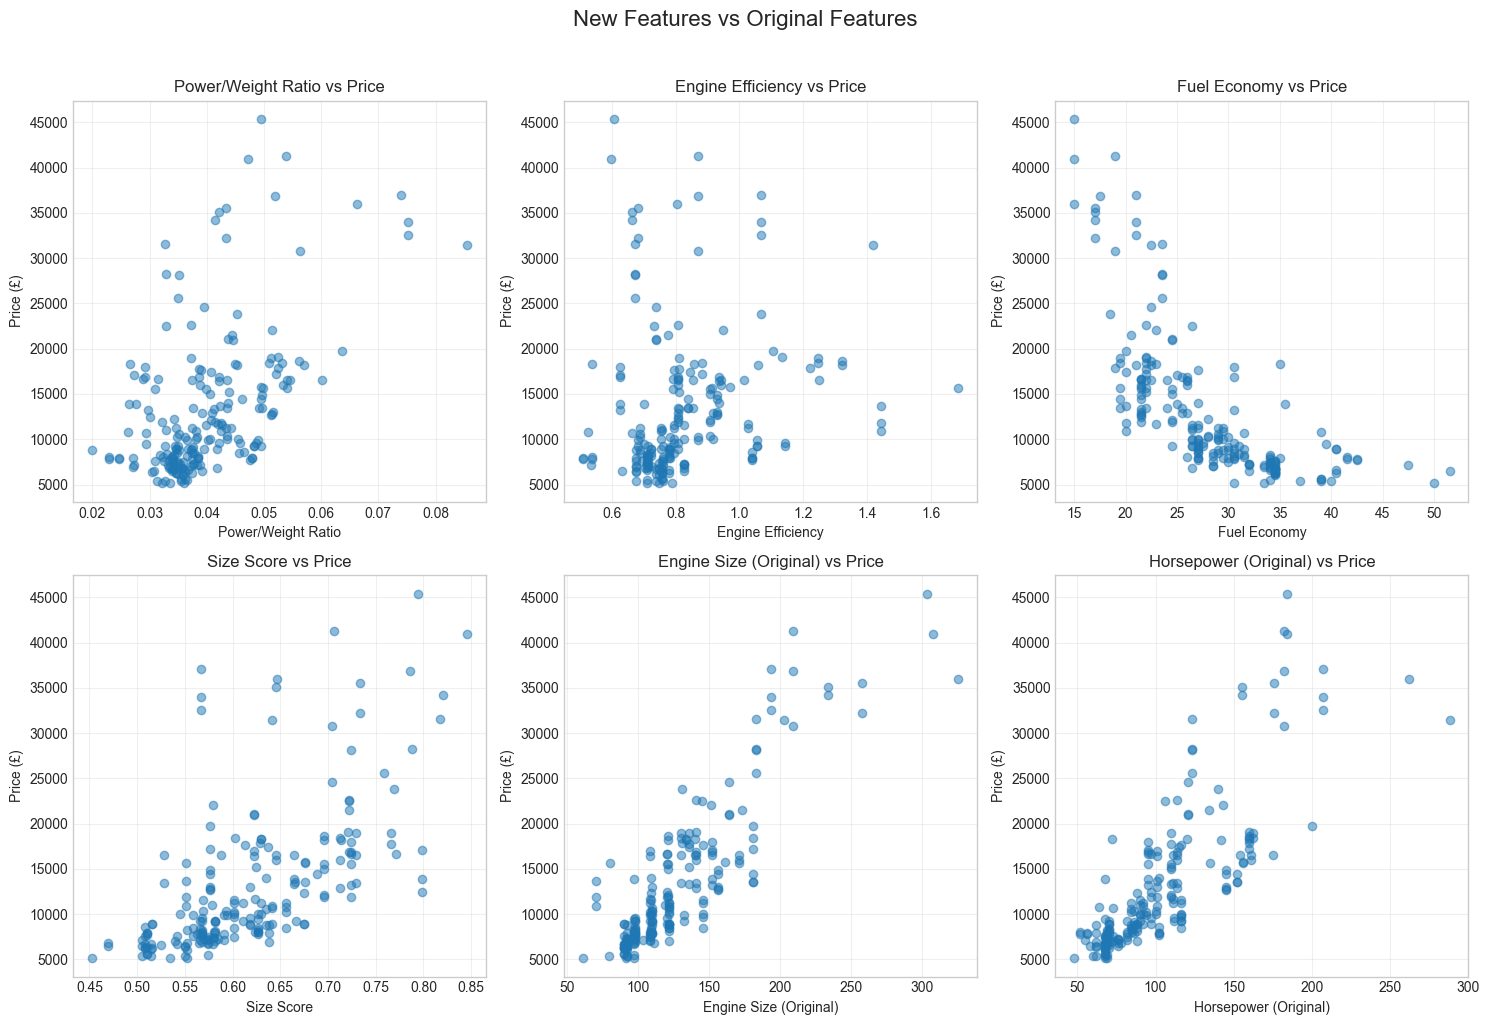

In [16]:
# Visualise how new features relate to price
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features_to_plot = [
    ('power_to_weight', 'Power/Weight Ratio'),
    ('engine_efficiency', 'Engine Efficiency'),
    ('fuel_economy', 'Fuel Economy'),
    ('size_score', 'Size Score'),
    ('enginesize', 'Engine Size (Original)'),
    ('horsepower', 'Horsepower (Original)')
]

for idx, (feature, title) in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].scatter(df[feature], df['price'], alpha=0.5)
    axes[row, col].set_xlabel(title)
    axes[row, col].set_ylabel('Price (£)')
    axes[row, col].set_title(f'{title} vs Price')
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('New Features vs Original Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Part 3: Understanding More Metrics

### Let's learn new ways to measure model performance!

In [17]:
# Prepare data for demonstrations
# Select numerical features for regression
regression_features = ['enginesize', 'horsepower', 'curbweight', 
                       'power_to_weight', 'engine_efficiency', 'fuel_economy']

X_reg = df[regression_features]

# Create classification target (Economy vs Luxury)
df['price_category'] = (df['price'] > df['price'].median()).astype(int)

In [18]:
df['price_category']

0      1
1      1
2      1
3      1
4      1
      ..
200    1
201    1
202    1
203    1
204    1
Name: price_category, Length: 205, dtype: int32

In [19]:
y_class = df['price_category']
y_reg = df['price']

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_reg, y_class, test_size=0.2, random_state=42)

In [20]:
# REGRESSION METRICS
print("REGRESSION METRICS EXPLAINED\n")
print("=" * 50)

# Train a simple model
model = LinearRegression()
model.fit(X_train_r, y_train_r)
y_pred = model.predict(X_test_r)

# Calculate all metrics
mae = mean_absolute_error(y_test_r, y_pred)
mse = mean_squared_error(y_test_r, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred)

print("MAE (Mean Absolute Error)")
print(f"   Value: £{mae:,.0f}")
print(f"   Meaning: Average error in pounds")
print(f"   Use when: You want simple interpretation\n")

print("RMSE (Root Mean Squared Error)")
print(f"   Value: £{rmse:,.0f}")
print(f"   Meaning: Like MAE but punishes big errors more")
print(f"   Use when: Large errors are really bad\n")

print("R² Score")
print(f"   Value: {r2:.2%}")
print(f"   Meaning: {r2:.1%} of price variation explained")
print(f"   Use when: You want a percentage score\n")

print("Quick comparison:")
print(f"   MAE = £{mae:,.0f} (simple average)")
print(f"   RMSE = £{rmse:,.0f} (penalises outliers)")
print(f"   Notice: RMSE > MAE because it penalises big errors!")

REGRESSION METRICS EXPLAINED

MAE (Mean Absolute Error)
   Value: £2,633
   Meaning: Average error in pounds
   Use when: You want simple interpretation

RMSE (Root Mean Squared Error)
   Value: £3,690
   Meaning: Like MAE but punishes big errors more
   Use when: Large errors are really bad

R² Score
   Value: 82.75%
   Meaning: 82.8% of price variation explained
   Use when: You want a percentage score

Quick comparison:
   MAE = £2,633 (simple average)
   RMSE = £3,690 (penalises outliers)
   Notice: RMSE > MAE because it penalises big errors!


In [21]:
# CLASSIFICATION METRICS
print("CLASSIFICATION METRICS EXPLAINED\n")
print("=" * 50)

# Train a simple model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_c, y_train_c)
y_pred_c = model.predict(X_test_c)

# Calculate metrics
accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("Accuracy")
print(f"   Value: {accuracy:.1%}")
print(f"   Meaning: Overall correct predictions\n")

print("Precision")
print(f"   Value: {precision:.1%}")
print(f"   Meaning: When we predict 'Luxury', how often are we right?")
print(f"   Use when: False positives are costly\n")

print("Recall")
print(f"   Value: {recall:.1%}")
print(f"   Meaning: Of all actual 'Luxury' cars, how many did we find?")
print(f"   Use when: Missing positives is costly\n")

print("F1 Score")
print(f"   Value: {f1:.1%}")
print(f"   Meaning: Balance between Precision and Recall")
print(f"   Formula: 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   Use when: You want balanced performance\n")

print("💡 Real Example - Spam Filter:")
print("   High Precision = Few real emails marked as spam (good!)")
print("   High Recall = Most spam emails caught (good!)")
print("   F1 Score = Overall spam filter quality")

CLASSIFICATION METRICS EXPLAINED

Accuracy
   Value: 95.1%
   Meaning: Overall correct predictions

Precision
   Value: 90.0%
   Meaning: When we predict 'Luxury', how often are we right?
   Use when: False positives are costly

Recall
   Value: 100.0%
   Meaning: Of all actual 'Luxury' cars, how many did we find?
   Use when: Missing positives is costly

F1 Score
   Value: 94.7%
   Meaning: Balance between Precision and Recall
   Formula: 2 × (Precision × Recall) / (Precision + Recall)
   Use when: You want balanced performance

💡 Real Example - Spam Filter:
   High Precision = Few real emails marked as spam (good!)
   High Recall = Most spam emails caught (good!)
   F1 Score = Overall spam filter quality


## Part 4: Overfitting vs Underfitting

### The Goldilocks Problem: Not too simple, not too complex!

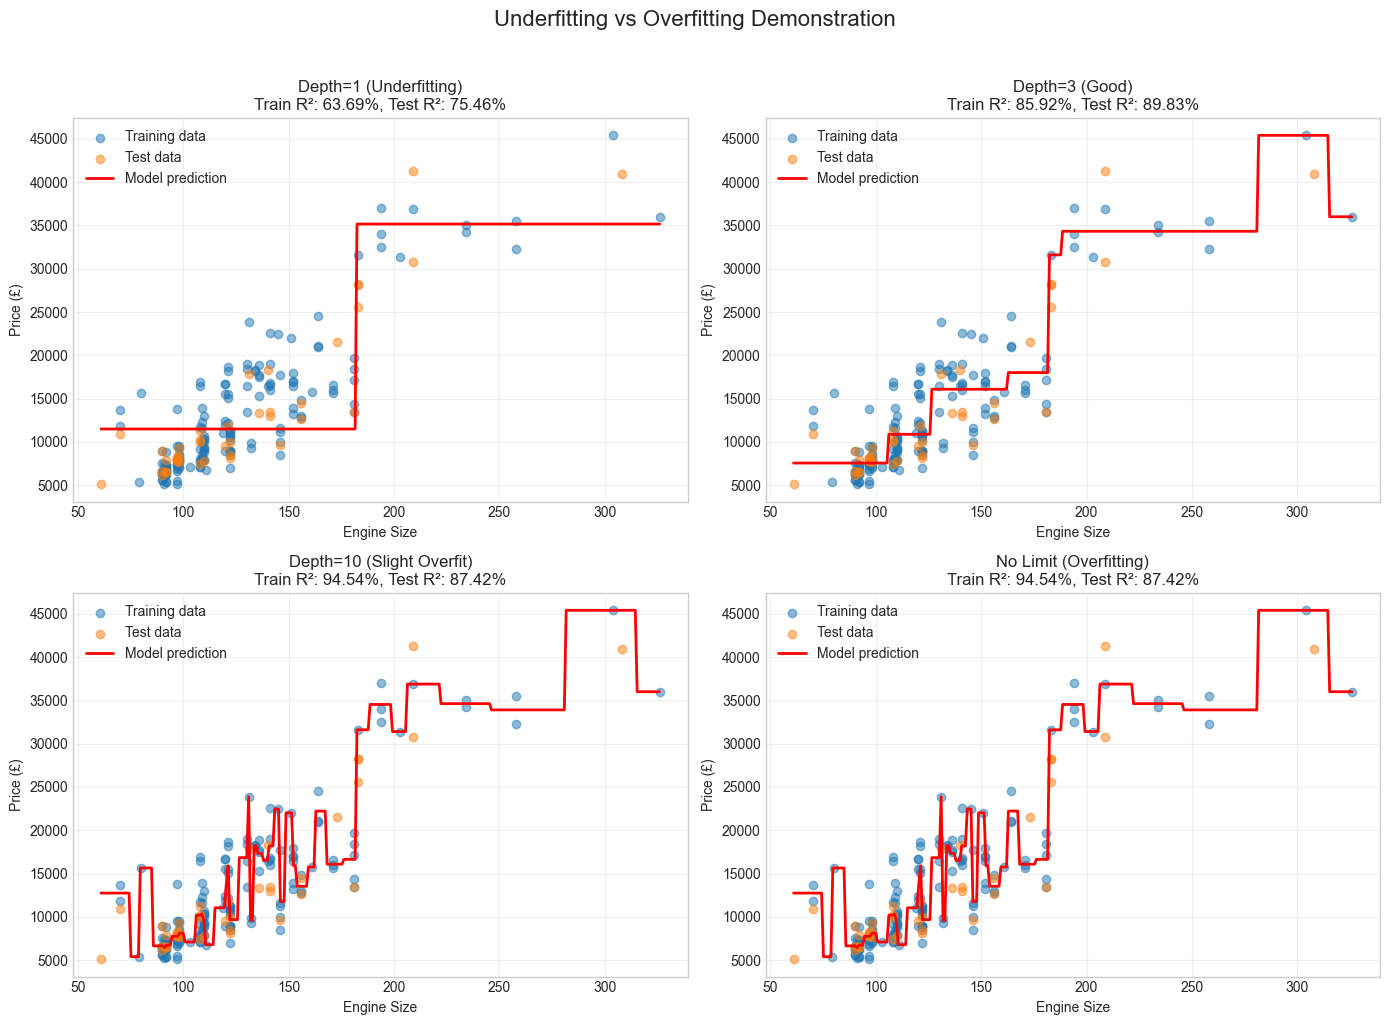

KEY OBSERVATIONS:
1. Underfitting (too simple): Poor on both train AND test
2. Good fit: Good on both train and test
3. Overfitting (too complex): Perfect on train, poor on test


In [22]:
# Demonstrate with Decision Trees of different depths
from sklearn.tree import DecisionTreeRegressor

# Prepare simple data
X_simple = df[['enginesize']]
y_simple = df['price']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Train trees with different complexities
depths = [1, 3, 10, None]  # None means no limit
models = []
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_s, y_train_s)
    models.append(model)
    
    # Calculate R² scores
    train_score = model.score(X_train_s, y_train_s)
    test_score = model.score(X_test_s, y_test_s)
    train_scores.append(train_score)
    test_scores.append(test_score)

# Visualise the different models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Underfitting vs Overfitting Demonstration', fontsize=16, y=1.02)

depth_names = ['Depth=1 (Underfitting)', 'Depth=3 (Good)', 'Depth=10 (Slight Overfit)', 'No Limit (Overfitting)']

for idx, (model, depth_name, train_sc, test_sc) in enumerate(zip(models, depth_names, train_scores, test_scores)):
    ax = axes[idx//2, idx%2]
    
    # Plot data
    ax.scatter(X_train_s, y_train_s, alpha=0.5, label='Training data')
    ax.scatter(X_test_s, y_test_s, alpha=0.5, label='Test data')
    
    # Plot predictions
    X_range = np.linspace(X_simple.min(), X_simple.max(), 300)
    y_range = model.predict(X_range)
    ax.plot(X_range, y_range, 'r-', linewidth=2, label='Model prediction')
    
    ax.set_xlabel('Engine Size')
    ax.set_ylabel('Price (£)')
    ax.set_title(f'{depth_name}\nTrain R²: {train_sc:.2%}, Test R²: {test_sc:.2%}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print("1. Underfitting (too simple): Poor on both train AND test")
print("2. Good fit: Good on both train and test")
print("3. Overfitting (too complex): Perfect on train, poor on test")

## Part 5: Cross-Validation

### One test isn't enough - let's test multiple times!

In [23]:
# Simple explanation of cross-validation
print("CROSS-VALIDATION EXPLAINED\n")
print("Problem: What if our test set was 'lucky' or 'unlucky'?")
print("Solution: Test multiple times with different splits!\n")

# Visual representation
print("How 5-Fold Cross-Validation Works:")
print("=" * 40)
print("Fold 1:   [TEST][TRAIN][TRAIN][TRAIN][TRAIN]")
print("Fold 2:   [TRAIN][TEST][TRAIN][TRAIN][TRAIN]")
print("Fold 3:   [TRAIN][TRAIN][TEST][TRAIN][TRAIN]")
print("Fold 4:   [TRAIN][TRAIN][TRAIN][TEST][TRAIN]")
print("Fold 5:   [TRAIN][TRAIN][TRAIN][TRAIN][TEST]")
print("Each part gets to be test set once!")

CROSS-VALIDATION EXPLAINED

Problem: What if our test set was 'lucky' or 'unlucky'?
Solution: Test multiple times with different splits!

How 5-Fold Cross-Validation Works:
Fold 1:   [TEST][TRAIN][TRAIN][TRAIN][TRAIN]
Fold 2:   [TRAIN][TEST][TRAIN][TRAIN][TRAIN]
Fold 3:   [TRAIN][TRAIN][TEST][TRAIN][TRAIN]
Fold 4:   [TRAIN][TRAIN][TRAIN][TEST][TRAIN]
Fold 5:   [TRAIN][TRAIN][TRAIN][TRAIN][TEST]
Each part gets to be test set once!


In [24]:
# Demonstrate cross-validation
from sklearn.model_selection import cross_val_score

# Simple model
model = LinearRegression()

# Single train-test split (what we did before)
model.fit(X_train_r, y_train_r)
single_score = model.score(X_test_r, y_test_r)

# Cross-validation (5 different tests)
cv_scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')

print("COMPARISON:\n")
print(f"Single test score: {single_score:.2%}")
print(f"Cross-validation scores (5 tests):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Test {i}: {score:.2%}")

print(f"Average CV score: {cv_scores.mean():.2%}")
print(f"Standard deviation: {cv_scores.std():.2%}")

print("Benefits of Cross-Validation:")
print("1. More reliable estimate (average of 5 tests)")
print("2. Shows variability (how consistent is the model?)")
print("3. Uses ALL data for both training AND testing")

COMPARISON:

Single test score: 82.75%
Cross-validation scores (5 tests):
  Test 1: 75.40%
  Test 2: 76.98%
  Test 3: 7.29%
  Test 4: 51.10%
  Test 5: 30.23%
Average CV score: 48.20%
Standard deviation: 26.73%
Benefits of Cross-Validation:
1. More reliable estimate (average of 5 tests)
2. Shows variability (how consistent is the model?)
3. Uses ALL data for both training AND testing


## Part 6: Comparing Different Algorithms (20 minutes)

### Let's try different models and see which works best!

In [25]:
# REGRESSION ALGORITHMS COMPARISON
print("TESTING DIFFERENT REGRESSION ALGORITHMS\n")

# Define simple algorithms to test
regression_models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)),
    ('K-Neighbors', KNeighborsRegressor(n_neighbors=5))
]

# Store results
results_reg = []

print("Testing each algorithm with 5-fold cross-validation...\n")
for name, model in regression_models:
    # Get cross-validation scores
    scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')
    results_reg.append(scores)
    
    print(f"{name:20} | Avg R²: {scores.mean():.2%} | Std: {scores.std():.2%}")

TESTING DIFFERENT REGRESSION ALGORITHMS

Testing each algorithm with 5-fold cross-validation...

Linear Regression    | Avg R²: 48.20% | Std: 26.73%
Decision Tree        | Avg R²: 33.10% | Std: 75.36%
Random Forest        | Avg R²: 45.37% | Std: 73.89%
K-Neighbors          | Avg R²: 41.01% | Std: 51.51%


In [26]:
# CLASSIFICATION ALGORITHMS COMPARISON
print("TESTING DIFFERENT CLASSIFICATION ALGORITHMS\n")

# Define simple algorithms to test
classification_models = [
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)),
    ('K-Neighbors', KNeighborsClassifier(n_neighbors=5))
]

# Store results for different metrics
results_acc = []
results_f1 = []

print("Testing each algorithm...\n")
for name, model in classification_models:
    # Accuracy scores
    acc_scores = cross_val_score(model, X_reg, y_class, cv=5, scoring='accuracy')
    results_acc.append(acc_scores)
    
    # F1 scores
    f1_scores = cross_val_score(model, X_reg, y_class, cv=5, scoring='f1')
    results_f1.append(f1_scores)
    
    print(f"{name:20} | Accuracy: {acc_scores.mean():.2%} | F1: {f1_scores.mean():.2%}")

TESTING DIFFERENT CLASSIFICATION ALGORITHMS

Testing each algorithm...

Logistic Regression  | Accuracy: 85.85% | F1: 85.76%
Decision Tree        | Accuracy: 85.37% | F1: 84.98%
Random Forest        | Accuracy: 89.27% | F1: 89.29%
K-Neighbors          | Accuracy: 85.85% | F1: 85.10%


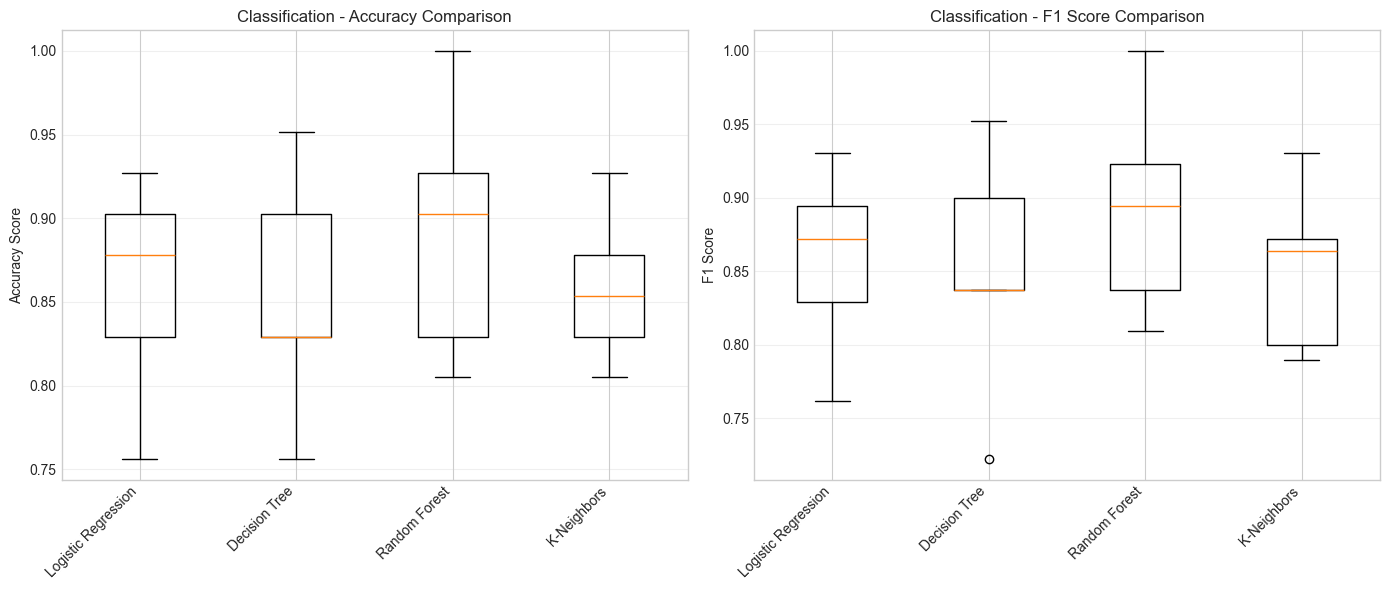

Best for Accuracy: Random Forest
Best for F1 Score: Random Forest


In [27]:
# Visualise classification results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy boxplot
bp1 = axes[0].boxplot(results_acc, labels=[name for name, _ in classification_models])
axes[0].set_ylabel('Accuracy Score')
axes[0].set_title('Classification - Accuracy Comparison')
axes[0].set_xticklabels([name for name, _ in classification_models], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# F1 Score boxplot
bp2 = axes[1].boxplot(results_f1, labels=[name for name, _ in classification_models])
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Classification - F1 Score Comparison')
axes[1].set_xticklabels([name for name, _ in classification_models], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Find best models
best_acc_idx = np.argmax([np.mean(scores) for scores in results_acc])
best_f1_idx = np.argmax([np.mean(scores) for scores in results_f1])

print(f"Best for Accuracy: {classification_models[best_acc_idx][0]}")
print(f"Best for F1 Score: {classification_models[best_f1_idx][0]}")

## Part 7: Understanding Algorithm Differences

In [28]:
print("QUICK GUIDE TO EACH ALGORITHM\n")
print("=" * 60)

print("LINEAR/LOGISTIC REGRESSION")
print("  How it works: Finds best straight line/boundary")
print("  Pros: Simple, fast, interpretable")
print("  Cons: Only captures linear relationships")
print("  Use when: Relationships are roughly linear\n")

print("DECISION TREE")
print("  How it works: Series of if-then rules")
print("  Pros: Easy to understand, handles non-linear")
print("  Cons: Can overfit easily")
print("  Use when: You need to explain decisions\n")

print("RANDOM FOREST")
print("  How it works: Many decision trees voting")
print("  Pros: Usually most accurate, less overfitting")
print("  Cons: Slower, harder to interpret")
print("  Use when: You want best accuracy\n")

print("K-NEAREST NEIGHBORS")
print("  How it works: Looks at similar examples")
print("  Pros: Simple concept, no training needed")
print("  Cons: Slow with big data, sensitive to scale")
print("  Use when: Similar items behave similarly")

QUICK GUIDE TO EACH ALGORITHM

LINEAR/LOGISTIC REGRESSION
  How it works: Finds best straight line/boundary
  Pros: Simple, fast, interpretable
  Cons: Only captures linear relationships
  Use when: Relationships are roughly linear

DECISION TREE
  How it works: Series of if-then rules
  Pros: Easy to understand, handles non-linear
  Cons: Can overfit easily
  Use when: You need to explain decisions

RANDOM FOREST
  How it works: Many decision trees voting
  Pros: Usually most accurate, less overfitting
  Cons: Slower, harder to interpret
  Use when: You want best accuracy

K-NEAREST NEIGHBORS
  How it works: Looks at similar examples
  Pros: Simple concept, no training needed
  Cons: Slow with big data, sensitive to scale
  Use when: Similar items behave similarly


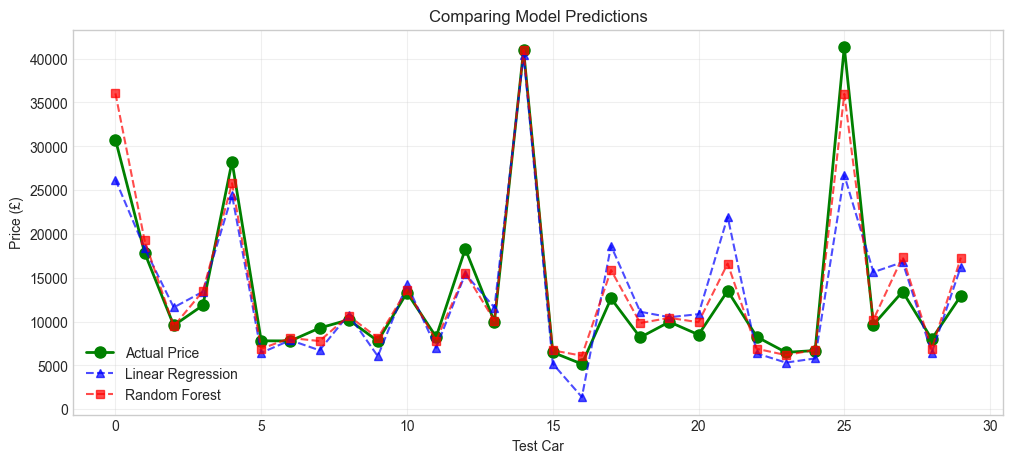

Linear Regression MAE: £2,633
Random Forest MAE: £1,517
Improvement: 42.4% better predictions!


In [29]:
# Visual comparison of predictions
# Train best models on full data
best_reg_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
best_reg_model.fit(X_train_r, y_train_r)
y_pred_best = best_reg_model.predict(X_test_r)

simple_model = LinearRegression()
simple_model.fit(X_train_r, y_train_r)
y_pred_simple = simple_model.predict(X_test_r)

# Plot comparison
plt.figure(figsize=(12, 5))

# First 30 predictions
n_show = 30
x_axis = range(n_show)

plt.plot(x_axis, y_test_r.values[:n_show], 'go-', label='Actual Price', markersize=8, linewidth=2)
plt.plot(x_axis, y_pred_simple[:n_show], 'b^--', label='Linear Regression', markersize=6, alpha=0.7)
plt.plot(x_axis, y_pred_best[:n_show], 'rs--', label='Random Forest', markersize=6, alpha=0.7)

plt.xlabel('Test Car')
plt.ylabel('Price (£)')
plt.title('Comparing Model Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate improvement
mae_simple = mean_absolute_error(y_test_r, y_pred_simple)
mae_best = mean_absolute_error(y_test_r, y_pred_best)

print(f"Linear Regression MAE: £{mae_simple:,.0f}")
print(f"Random Forest MAE: £{mae_best:,.0f}")
print(f"Improvement: {(1 - mae_best/mae_simple)*100:.1f}% better predictions!")

## Part 8: Feature Importance

### Which features matter most?

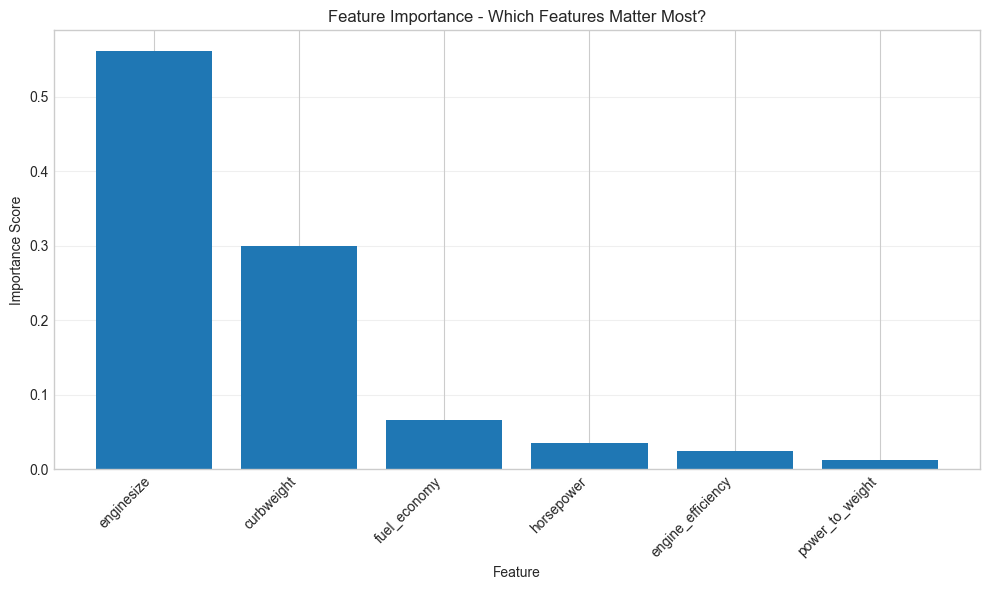

FEATURE IMPORTANCE RANKING:
1. enginesize           | Importance: 0.561
2. curbweight           | Importance: 0.300
3. fuel_economy         | Importance: 0.067
4. horsepower           | Importance: 0.035
5. engine_efficiency    | Importance: 0.024
6. power_to_weight      | Importance: 0.012
Insights:
• Top feature 'enginesize' is 45.9x more important than the least
• Top 3 features explain 92.8% of importance


In [30]:
# Get feature importance from Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_r, y_train_r)

# Get importances
importances = rf_model.feature_importances_
feature_names = regression_features

# Sort features by importance
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Feature Importance - Which Features Matter Most?')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("FEATURE IMPORTANCE RANKING:")
print("=" * 40)
for i, idx in enumerate(indices, 1):
    print(f"{i}. {feature_names[idx]:20} | Importance: {importances[idx]:.3f}")

print("Insights:")
print(f"• Top feature '{feature_names[indices[0]]}' is {importances[indices[0]]/importances[indices[-1]]:.1f}x more important than the least")
print(f"• Top 3 features explain {sum(importances[indices[:3]]):.1%} of importance")

## Part 9: Hyperparameter Tuning

### Finding the perfect settings for your model!

In [31]:
print("WHAT ARE HYPERPARAMETERS?\n")
print("=" * 50)
print("Think of them as SETTINGS you choose BEFORE training:\n")
print("Regular Parameters (learned from data):")
print("   • Weights in linear regression")
print("   • Split points in decision trees")
print("   • These are LEARNED automatically\n")
print("Hyperparameters (you choose):")
print("   • How deep can a tree grow?")
print("   • How many trees in a forest?")
print("   • How many neighbors to check?")
print("   • These are SET by you\n")
print("Analogy: Like choosing oven temperature (hyperparameter)")
print("           vs how long the cake actually takes (learned)")

WHAT ARE HYPERPARAMETERS?

Think of them as SETTINGS you choose BEFORE training:

Regular Parameters (learned from data):
   • Weights in linear regression
   • Split points in decision trees
   • These are LEARNED automatically

Hyperparameters (you choose):
   • How deep can a tree grow?
   • How many trees in a forest?
   • How many neighbors to check?
   • These are SET by you

Analogy: Like choosing oven temperature (hyperparameter)
           vs how long the cake actually takes (learned)


In [32]:
# Let's tune a Decision Tree - simple and visual!
from sklearn.model_selection import GridSearchCV

print("TUNING A DECISION TREE\n")

# Simple parameters to try
param_grid = {
    'max_depth': [2, 3, 5, 7, 10],  # How deep can tree grow?
    'min_samples_split': [2, 5, 10]  # Min samples to split a node
}

print("Parameters we'll test:")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  min_samples_split: {param_grid['min_samples_split']}")
print(f"\nTotal combinations: {len(param_grid['max_depth']) * len(param_grid['min_samples_split'])}")

TUNING A DECISION TREE

Parameters we'll test:
  max_depth: [2, 3, 5, 7, 10]
  min_samples_split: [2, 5, 10]

Total combinations: 15


In [33]:
# Run Grid Search
print("SEARCHING FOR BEST PARAMETERS...\n")

# Create grid search
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1  # Use all CPU cores
)

# Fit grid search
grid_search.fit(X_train_r, y_train_r)

print("Search complete!\n")
print(f"BEST PARAMETERS FOUND:")
print(f"   max_depth: {grid_search.best_params_['max_depth']}")
print(f"   min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"Best cross-validation score: {grid_search.best_score_:.2%}")

# Compare to default
default_tree = DecisionTreeRegressor(random_state=42)
default_scores = cross_val_score(default_tree, X_train_r, y_train_r, cv=5, scoring='r2')
print(f"Default parameters score: {default_scores.mean():.2%}")


SEARCHING FOR BEST PARAMETERS...

Search complete!

BEST PARAMETERS FOUND:
   max_depth: 10
   min_samples_split: 2
Best cross-validation score: 85.88%
Default parameters score: 84.26%


In [ ]:
# Summary of hyperparameter tuning
print("HYPERPARAMETER TUNING SUMMARY\n")
print("=" * 50)

print("What we learned:\n")
print("1. Hyperparameters are settings YOU choose")
print("2. Grid Search tries all combinations")
print("3. Use cross-validation to avoid overfitting")
print("4. There's usually a 'sweet spot'")
print("5. More complex ≠ always better\n")

print("Practical tips:")
print("• Start with few parameters (2-3)")
print("• Use coarse grid first (big jumps)")
print("• Then fine-tune around best values")
print("• Always check test set performance\n")

print("Warning signs of overfitting:")
print("• Training score much higher than test")
print("• Very deep trees or many parameters")
print("• Performance drops on new data")

## Summary: What You've Learned! 

### Today's Achievements:
1. **Data Preparation** - Handled missing values and outliers
2. **Feature Engineering** - Created 6 new smart features
3. **New Metrics** - Learned RMSE, F1 Score, Precision, Recall
4. **Overfitting/Underfitting** - Found the 'Goldilocks' zone
5. **Cross-Validation** - More reliable testing
6. **Algorithm Comparison** - Tested 4 different models
7. **Feature Importance** - Discovered what matters most
8. **Hyperparameter Tuning** - Found optimal model settings

### Key Takeaways:

#### Metrics Summary
| Task | Metrics | Best When |
|------|---------|----------|
| **Regression** | MAE, RMSE, R² | RMSE when outliers matter |
| **Classification** | Accuracy, Precision, Recall, F1 | F1 for balanced performance |

#### Algorithm Performance
- **Random Forest** often wins (but slower)
- **Linear/Logistic** fast and interpretable
- **Decision Trees** good for explanation
- **K-Neighbors** simple but can be slow

#### Best Practices
1. Always use cross-validation
2. Create meaningful features
3. Compare multiple algorithms
4. Watch for overfitting
5. Choose metrics that matter for your problem

## Putting It All Together - Final Model

In [ ]:
# Build our best model with everything we learned
print("BUILDING OUR BEST MODEL\n")

# Use all our engineered features
all_features = ['enginesize', 'horsepower', 'curbweight', 'citympg', 'highwaympg',
                'power_to_weight', 'engine_efficiency', 'fuel_economy', 'size_score', 'is_luxury']

X_final = df[all_features]
y_final = df['price']

# Split data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Train best model
best_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
best_model.fit(X_train_f, y_train_f)

# Make predictions
y_pred_final = best_model.predict(X_test_f)

# Calculate all metrics
mae_final = mean_absolute_error(y_test_f, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_f, y_pred_final))
r2_final = r2_score(y_test_f, y_pred_final)

print("FINAL MODEL PERFORMANCE:")
print("=" * 40)
print(f"MAE:  £{mae_final:,.0f}")
print(f"RMSE: £{rmse_final:,.0f}")
print(f"R²:   {r2_final:.2%}")

# Compare to Part 1
print("IMPROVEMENT FROM PART 1:")
print("Part 1 (Basic): R² = ~80%")
print(f"Part 2 (Advanced): R² = {r2_final:.1%}")

In [ ]:
# Make an interactive prediction
print("LET'S PREDICT A CUSTOM CAR PRICE!\n")

# You can change these values!
custom_car = {
    'enginesize': 150,
    'horsepower': 130,
    'curbweight': 2800,
    'citympg': 28,
    'highwaympg': 35,
    'power_to_weight': 130/2800,  # Calculate ratio
    'engine_efficiency': 130/150,   # Calculate efficiency
    'fuel_economy': (28+35)/2,      # Average MPG
    'size_score': 2.5,               # Medium size
    'is_luxury': 0                   # Not luxury brand
}

# Make prediction
custom_features = [[custom_car[f] for f in all_features]]
predicted_price = best_model.predict(custom_features)[0]

print("Car Specifications:")
print("-" * 30)
print(f"Engine: {custom_car['enginesize']}cc, {custom_car['horsepower']}hp")
print(f"Weight: {custom_car['curbweight']} lbs")
print(f"Economy: {custom_car['citympg']} city / {custom_car['highwaympg']} highway")
print(f"Luxury brand: {'Yes' if custom_car['is_luxury'] else 'No'}")

print(f"PREDICTED PRICE: £{predicted_price:,.0f}")
